<a href="https://colab.research.google.com/github/LukaM286/movie-success-prediction/blob/main/movie_success_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving tmdb_5000_credits.csv to tmdb_5000_credits.csv
Saving tmdb_5000_movies.csv to tmdb_5000_movies.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast  # parsing JSON-like

In [3]:
movies = pd.read_csv('tmdb_5000_movies.csv')
credits = pd.read_csv('tmdb_5000_credits.csv')

# merge by title
credits = credits.rename(columns={'movie_id': 'id'})
movies = movies.merge(credits, on='id', suffixes=('', '_credits'))

print(movies.shape)
print(movies.head(3))

(4803, 23)
      budget                                             genres  \
0  237000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   
1  300000000  [{"id": 12, "name": "Adventure"}, {"id": 14, "...   
2  245000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   

                                       homepage      id  \
0                   http://www.avatarmovie.com/   19995   
1  http://disney.go.com/disneypictures/pirates/     285   
2   http://www.sonypictures.com/movies/spectre/  206647   

                                            keywords original_language  \
0  [{"id": 1463, "name": "culture clash"}, {"id":...                en   
1  [{"id": 270, "name": "ocean"}, {"id": 726, "na...                en   
2  [{"id": 470, "name": "spy"}, {"id": 818, "name...                en   

                             original_title  \
0                                    Avatar   
1  Pirates of the Caribbean: At World's End   
2                                   Spectre  

In [4]:
# drop
cols_to_keep = ['budget', 'revenue', 'runtime', 'popularity',
                'release_date', 'genres', 'vote_average', 'vote_count']

movies = movies[cols_to_keep]
print(movies.isnull().sum())  #missing

budget          0
revenue         0
runtime         2
popularity      0
release_date    1
genres          0
vote_average    0
vote_count      0
dtype: int64


In [5]:
movies = movies[movies['budget'] > 0]
movies = movies[movies['revenue'] > 0]

movies = movies.dropna(subset=['runtime', 'release_date'])

print(f"Rows remaining: {len(movies)}")

Rows remaining: 3229


In [6]:
# current threshold will be movie is successf if revenue is at least 2x the budget
movies['success'] = (movies['revenue'] >= 2 * movies['budget']).astype(int)

# check balance
print(movies['success'].value_counts())
print(movies['success'].value_counts(normalize=True).round(2)) #next is to extract genres

success
1    1809
0    1420
Name: count, dtype: int64
success
1    0.56
0    0.44
Name: proportion, dtype: float64


In [8]:
def get_genres(genre_string):
    try:
        genres = ast.literal_eval(genre_string)  #convert
        return [g['name'] for g in genres]
    except:
        return []

movies['genre_list'] = movies['genres'].apply(get_genres)

# top 10 most commmon
from collections import Counter
all_genres = [g for sublist in movies['genre_list'] for g in sublist]
top_genres = [g for g, _ in Counter(all_genres).most_common(10)]
print(top_genres)

['Drama', 'Comedy', 'Thriller', 'Action', 'Adventure', 'Romance', 'Crime', 'Science Fiction', 'Family', 'Fantasy']


In [9]:
# create a binary column for each top genre (1 = movie has this genre, 0 = it doesn't)
for genre in top_genres:
    movies[genre] = movies['genre_list'].apply(lambda x: int(genre in x))

print(movies[top_genres].head())

   Drama  Comedy  Thriller  Action  Adventure  Romance  Crime  \
0      0       0         0       1          1        0      0   
1      0       0         0       1          1        0      0   
2      0       0         0       1          1        0      1   
3      1       0         1       1          0        0      1   
4      0       0         0       1          1        0      0   

   Science Fiction  Family  Fantasy  
0                1       0        1  
1                0       0        1  
2                0       0        0  
3                0       0        0  
4                1       0        0  


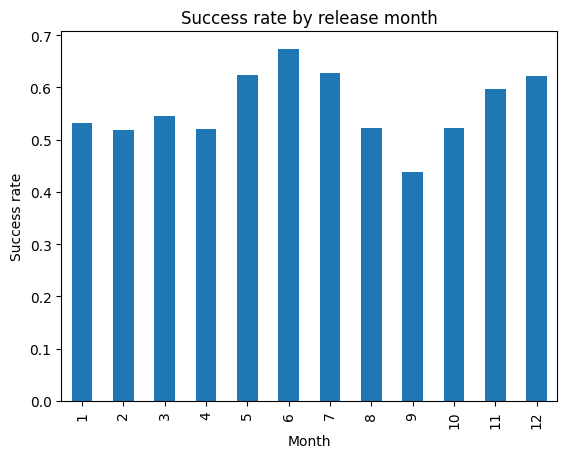

In [10]:
movies['release_date'] = pd.to_datetime(movies['release_date'])
movies['release_month'] = movies['release_date'].dt.month

# quick chart
movies.groupby('release_month')['success'].mean().plot(kind='bar')
plt.title('Success rate by release month')
plt.xlabel('Month')
plt.ylabel('Success rate')
plt.show()

In [11]:
feature_cols = ['budget', 'runtime', 'popularity', 'vote_average',
                'vote_count', 'release_month'] + top_genres

X = movies[feature_cols]
y = movies['success']

print(X.shape)  # should be (rows, ~16 features)
print(y.value_counts())

(3229, 16)
success
1    1809
0    1420
Name: count, dtype: int64


In [12]:
#splitting data to train and test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

Training samples: 2583
Testing samples:  646


In [13]:
#scaling features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)